# Training v2 — Phase 2 diagnostic curves + (optional) generative augmentation

This notebook addresses two pieces of advisor feedback on the original UAV face-recognition pipeline:

1. **Task 2 (this notebook, primary):** the original report claims the negative result (full pipeline underperforms the raw VGGFace2 backbone by ~6 pp on DroneFace) is *classical small-dataset overfitting*. The advisor wants concrete evidence — at minimum train/val loss curves over epochs. We re-run Phase 2 fine-tuning on top of the existing Phase 1 checkpoint and log per-epoch ArcFace loss + Rank-1 accuracy on three slices of the data: train identities (A–H), validation identity (I), and held-out test identities (J, K).
2. **Task 1 (later, optional):** generate ~1,200 synthetic identities with Stable Diffusion and re-run Phase 1 + Phase 2 to see if expanding identity diversity (rather than sample count) helps.

All artefacts go under `results/`.

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('/home/buthaina.almulla/Documents/CV7502/src')))

import os, sys, csv, copy, math, json, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import InceptionResnetV1

# Local modules
from dataset import DroneFaceDataset
from model import Embeddinghead, ArcFaceLoss

torch.manual_seed(42); torch.cuda.manual_seed_all(42); np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__, '|cuda:', torch.version.cuda)

/home/buthaina.almulla/Documents/CV7502/venv/lib/python3.10/site-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  st

device: cuda | NVIDIA RTX 5000 Ada Generation
torch: 2.4.1+cu121 |cuda: 12.1


In [2]:
# Paths (project layout has split/ under datasets/droneface/, not at project root,
# and checkpoints live under checkpoints/checkpoints/ — different from what the
# original training_fixed.ipynb hard-codes)
PROJECT = Path('/home/buthaina.almulla/Documents/CV7502')
SPLIT = PROJECT / 'datasets' / 'droneface' / 'split'
CKPT_DIR = PROJECT / 'checkpoints' / 'checkpoints'
PHASE1_CKPT = CKPT_DIR / 'best_model.pth'
RESULTS = PROJECT / 'results'
CURVES_DIR = RESULTS / 'training_curves'
CURVES_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters (from user spec — same as original Phase 2)
BATCH_SIZE = 32
EPOCHS = 50
LR_BACKBONE = 1e-6
LR_HEAD = 1e-4
ARCFACE_SCALE = 32.0
ARCFACE_MARGIN = 0.3

TRAIN_IDS = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
VAL_IDS = ['I']
HELDOUT_IDS = ['J', 'K']

for p in (SPLIT, PHASE1_CKPT):
    assert p.exists(), f'missing path: {p}'
print('paths verified')

paths verified


## Datasets

Four slices, all built from `datasets/droneface/split/`:

- `train_set` — 8 identities A–H, augmented (RandomResizedCrop, flip, rotation, blur, jitter). Used for the gradient step.
- `train_eval_set` — same 8 identities, **non-augmented** at 160×160 (matching the LOO eval used in the paper). Used for measuring train Rank-1.
- `val_eval_set` — identity I, non-augmented 160×160. Used for val Rank-1.
- `heldout_eval_set` — identities J,K, non-augmented 160×160. Used for held-out Rank-1.

**On val loss:** ArcFace cross-entropy requires a class index that exists in the trained ArcFace head. Identities I/J/K do not have class indices in the 8-way Phase 2 head, so we cannot compute ArcFace loss on them in the standard way. Instead we hold out **10% of A–H training images** as a val-loss subset (random per identity). Train loss is computed on the remaining 90%; val loss on the 10%. This gives the train/val divergence signal the advisor asked about, computed with the same loss formulation. We document this clearly in the interpretation cell at the end.

In [3]:
# Augmented training dataset (uses dataset.py's DroneFaceDataset with augment=True)
train_set = DroneFaceDataset(str(SPLIT / 'train'), augment=True)
num_train_classes = len(train_set.classes)
assert train_set.classes == TRAIN_IDS, f'unexpected train identities: {train_set.classes}'
print(f'train_set: {len(train_set)} images, {num_train_classes} classes ({train_set.classes})')

# Hold out 10% of train images for val-loss measurement (deterministic per-identity split)
rng = np.random.RandomState(42)
all_indices_by_label = {}
for i, lbl in enumerate(train_set.labels):
    all_indices_by_label.setdefault(lbl, []).append(i)
train_idx, valloss_idx = [], []
for lbl, idxs in all_indices_by_label.items():
    idxs = list(idxs); rng.shuffle(idxs)
    n_holdout = max(1, int(0.1 * len(idxs)))
    valloss_idx.extend(idxs[:n_holdout])
    train_idx.extend(idxs[n_holdout:])
print(f'train (gradient step): {len(train_idx)} images')
print(f'val-loss holdout from A-H: {len(valloss_idx)} images')

train_subset = Subset(train_set, train_idx)
valloss_subset_aug = Subset(train_set, valloss_idx)  # uses same train transform — matches train distribution

# Build a non-augmented twin of train_set so val-loss is measured on clean images.
# DroneFaceDataset(augment=False) re-scans the directory, so labels are identical
# in order to train_set (sorted listdir).
train_set_noaug = DroneFaceDataset(str(SPLIT / 'train'), augment=False)
assert train_set_noaug.image_paths == train_set.image_paths, 'image_paths differ — order mismatch!'
valloss_subset = Subset(train_set_noaug, valloss_idx)
print(f'val-loss subset (non-augmented): {len(valloss_subset)} images')

train_set: 992 images, 8 classes (['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'])
train (gradient step): 896 images
val-loss holdout from A-H: 96 images
val-loss subset (non-augmented): 96 images


In [4]:
# Eval transform — match the LOO eval transform used in the paper (160x160 + Normalize)
eval_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def list_images(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

def collect_eval_images(splits_to_ids):
    """Return list of (path, identity_label) for given split->ids mapping."""
    items = []
    for split, ids in splits_to_ids.items():
        for ident in ids:
            folder = SPLIT / split / ident
            for fname in list_images(folder):
                items.append((str(folder / fname), ident))
    return items

# All 11 identities in one pool — used for the LOO Rank-1 metric (train/val/heldout slices come from
# splitting per-identity Rank-1 by group)
eval_items_all = collect_eval_images({
    'train':      TRAIN_IDS,
    'validation': VAL_IDS,
    'test':       HELDOUT_IDS,
})
eval_paths = [p for p, _ in eval_items_all]
eval_labels = np.array([l for _, l in eval_items_all])
print(f'eval pool: {len(eval_items_all)} images, {len(np.unique(eval_labels))} identities')
for ident in sorted(np.unique(eval_labels)):
    print(f'  {ident}: {(eval_labels==ident).sum()}')

eval pool: 1364 images, 11 identities
  A: 124
  B: 124
  C: 124
  D: 124
  E: 124
  F: 124
  G: 124
  H: 124
  I: 124
  J: 124
  K: 124


## Model

Identical structure to the original Phase 2 setup:

- **Backbone**: `InceptionResnetV1(pretrained='vggface2')`. Most layers frozen; only `block8`, `avgpool_1a`, `last_linear`, `last_bn` are trainable (matches `training_fixed.ipynb` cell 12).
- **Head**: `Embeddinghead(input_dim=512, Embedding_dim=256)` — fc1+bn1+ReLU+dropout → fc2+bn2 → L2-normalize.
- **ArcFace**: `ArcFaceLoss(in_features=256, num_classes=8, scale=32.0, margin=0.3)`. Re-initialised (the Phase 1 ArcFace had 540 classes for VGGFace2 — incompatible).

We load Phase 1 weights into backbone + head, then start Phase 2.

In [5]:
backbone = InceptionResnetV1(pretrained='vggface2').to(device)
for p in backbone.parameters():
    p.requires_grad = False
for block in [backbone.block8, backbone.avgpool_1a, backbone.last_linear, backbone.last_bn]:
    for p in block.parameters():
        p.requires_grad = True

head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
arcface_drone = ArcFaceLoss(
    in_features=256, num_classes=num_train_classes,
    scale=ARCFACE_SCALE, margin=ARCFACE_MARGIN,
).to(device)

# Load Phase 1 checkpoint into backbone+head (skip arcface — incompatible class count)
ckpt = torch.load(str(PHASE1_CKPT), map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
print('loaded Phase 1 weights from', PHASE1_CKPT)

n_train = sum(p.numel() for p in backbone.parameters() if p.requires_grad) + \
          sum(p.numel() for p in head.parameters() if p.requires_grad) + \
          sum(p.numel() for p in arcface_drone.parameters() if p.requires_grad)
print(f'trainable params: {n_train:,}')

loaded Phase 1 weights from /home/buthaina.almulla/Documents/CV7502/checkpoints/checkpoints/best_model.pth
trainable params: 2,916,864


/tmp/slurm-buthaina.almulla-132120/ipykernel_3171299/1026512370.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(PHASE1_CKPT), map_location=device)

In [6]:
optimizer = torch.optim.Adam([
    {'params': [p for p in backbone.parameters() if p.requires_grad], 'lr': LR_BACKBONE},
    {'params': head.parameters(),          'lr': LR_HEAD},
    {'params': arcface_drone.parameters(), 'lr': LR_HEAD},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
valloss_loader = DataLoader(valloss_subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
print(f'train batches/epoch: {len(train_loader)} | valloss batches: {len(valloss_loader)}')

train batches/epoch: 28 | valloss batches: 3


## Eval helpers

In [7]:
@torch.no_grad()
def extract_embeddings(paths, batch=64):
    """Run backbone+head over a list of image paths in eval mode. Returns (N, 256) on CPU."""
    backbone.eval(); head.eval()
    out = []
    for start in range(0, len(paths), batch):
        chunk = paths[start:start+batch]
        imgs = torch.stack([
            eval_transform(Image.open(p).convert('RGB')) for p in chunk
        ]).to(device)
        emb = head(backbone(imgs))
        out.append(emb.cpu())
    return torch.cat(out, dim=0)

def loo_rank1_per_identity(embeddings, labels):
    """Leave-one-out cosine-centroid Rank-1 (matches the existing loo_eval protocol):
    centroid = mean of (other-identity-images), then L2-normalise; query L2-normalised at match.
    Returns dict identity -> (correct, total) and overall rank-1.
    """
    embeddings = embeddings.detach()
    labels = np.asarray(labels)
    unique = np.unique(labels)
    counts = {ident: int((labels == ident).sum()) for ident in unique}
    sums = {ident: embeddings[labels == ident].sum(dim=0) for ident in unique}

    # Pre-normalise queries
    q_norm = F.normalize(embeddings, p=2, dim=1)

    correct = {ident: 0 for ident in unique}
    total = {ident: 0 for ident in unique}

    n = embeddings.shape[0]
    # Build centroids matrix once per query: faster to recompute the affected centroid in a loop
    # Use vectorised approach: precompute centroid_sums and counts, then for each i adjust the
    # i-th identity's centroid by removing embeddings[i].
    centroid_labels = np.array(unique)
    base_centroids = torch.stack([sums[ident] / counts[ident] for ident in unique])  # (K, 256)
    base_centroids_n = F.normalize(base_centroids, p=2, dim=1)

    for i in range(n):
        ident_i = labels[i]
        # adjusted centroid for ident_i removing sample i
        if counts[ident_i] > 1:
            adj = (sums[ident_i] - embeddings[i]) / (counts[ident_i] - 1)
        else:
            # only one image of this identity — skip (cannot LOO)
            total[ident_i] += 1
            continue
        # build full centroid stack for this query
        cents = base_centroids.clone()
        cents[np.where(centroid_labels == ident_i)[0][0]] = adj
        cents = F.normalize(cents, p=2, dim=1)
        sims = cents @ q_norm[i]  # (K,)
        pred = centroid_labels[int(sims.argmax().item())]
        if pred == ident_i:
            correct[ident_i] += 1
        total[ident_i] += 1

    overall = sum(correct.values()) / max(1, sum(total.values())) * 100.0
    return {ident: (correct[ident], total[ident]) for ident in unique}, overall

## Training loop with per-epoch metrics

In [8]:
metrics = []  # list of dicts per epoch
best_val_rank1 = -1.0
best_epoch = -1

TRAIN_SET = set(TRAIN_IDS); VAL_SET = set(VAL_IDS); HELDOUT_SET = set(HELDOUT_IDS)

t_overall = time.time()
for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    # ---- training step
    backbone.train(); head.train(); arcface_drone.train()
    total_loss, n_batches = 0.0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        optimizer.zero_grad()
        proj = head(backbone(imgs))
        logits = arcface_drone(proj, lbls)
        loss = F.cross_entropy(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(backbone.parameters()) + list(head.parameters()) + list(arcface_drone.parameters()),
            max_norm=5.0,
        )
        optimizer.step()
        total_loss += float(loss.item()); n_batches += 1
    scheduler.step()
    train_loss = total_loss / max(1, n_batches)

    # ---- val-loss measurement on held-out 10% of A-H (no grad, no aug)
    backbone.eval(); head.eval(); arcface_drone.eval()
    with torch.no_grad():
        vl_total, vl_batches = 0.0, 0
        for imgs, lbls in valloss_loader:
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
            proj = head(backbone(imgs))
            logits = arcface_drone(proj, lbls)
            vl_total += float(F.cross_entropy(logits, lbls).item()); vl_batches += 1
        val_loss = vl_total / max(1, vl_batches)

    # ---- per-epoch LOO Rank-1 across all 11 identities, then aggregate by split
    embs = extract_embeddings(eval_paths, batch=64)
    per_id, _ = loo_rank1_per_identity(embs, eval_labels)
    def slice_acc(idents):
        c = sum(per_id[i][0] for i in idents); t = sum(per_id[i][1] for i in idents)
        return 100.0 * c / max(1, t)
    train_rank1 = slice_acc(TRAIN_IDS)
    val_rank1 = slice_acc(VAL_IDS)
    heldout_rank1 = slice_acc(HELDOUT_IDS)

    metrics.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_rank1': train_rank1,
        'val_rank1': val_rank1,
        'heldout_rank1': heldout_rank1,
    })

    saved = ''
    if val_rank1 > best_val_rank1:
        best_val_rank1 = val_rank1; best_epoch = epoch
        torch.save({
            'backbone': backbone.state_dict(),
            'head': head.state_dict(),
            'arcface': arcface_drone.state_dict(),
            'epoch': epoch,
            'val_rank1': val_rank1,
        }, str(CKPT_DIR / 'best_drone_model_v2.pth'))
        saved = ' (saved)'

    elapsed = time.time() - t_epoch
    print(
        f'epoch {epoch:>2}/{EPOCHS}  '
        f'train_loss={train_loss:6.4f}  val_loss={val_loss:6.4f}  '
        f'tr_R1={train_rank1:5.1f}%  val_R1={val_rank1:5.1f}%  ho_R1={heldout_rank1:5.1f}%  '
        f'[{elapsed:4.1f}s]{saved}'
    )

print(f'\ntotal: {time.time()-t_overall:.1f}s | best val Rank-1 {best_val_rank1:.2f}% at epoch {best_epoch}')

epoch  1/50  train_loss=10.5525  val_loss=10.3903  tr_R1= 54.3%  val_R1= 49.2%  ho_R1= 50.4%  [ 3.5s] (saved)


epoch  2/50  train_loss=7.8148  val_loss=9.7180  tr_R1= 50.6%  val_R1= 36.3%  ho_R1= 43.5%  [ 2.3s]


epoch  3/50  train_loss=6.2014  val_loss=7.9136  tr_R1= 58.9%  val_R1= 48.4%  ho_R1= 56.5%  [ 2.1s]


epoch  4/50  train_loss=5.1829  val_loss=6.2095  tr_R1= 64.5%  val_R1= 58.9%  ho_R1= 68.1%  [ 2.3s] (saved)


epoch  5/50  train_loss=4.6430  val_loss=5.3567  tr_R1= 67.5%  val_R1= 61.3%  ho_R1= 70.2%  [ 2.2s] (saved)


...

epoch 46/50  train_loss=1.9402  val_loss=2.6436  tr_R1= 81.4%  val_R1= 69.4%  ho_R1= 70.6%  [ 2.1s]


epoch 47/50  train_loss=2.1639  val_loss=5.4588  tr_R1= 75.1%  val_R1= 58.9%  ho_R1= 70.6%  [ 2.1s]


epoch 48/50  train_loss=1.9644  val_loss=2.1448  tr_R1= 84.2%  val_R1= 67.7%  ho_R1= 71.4%  [ 2.2s]


epoch 49/50  train_loss=2.0055  val_loss=1.6546  tr_R1= 86.2%  val_R1= 66.1%  ho_R1= 69.0%  [ 2.1s]


epoch 50/50  train_loss=2.0214  val_loss=3.2077  tr_R1= 80.9%  val_R1= 62.1%  ho_R1= 72.2%  [ 2.1s]

total: 107.6s | best val Rank-1 70.97% at epoch 27


## Save metrics + plots

wrote /home/buthaina.almulla/Documents/CV7502/results/training_curves/phase2_per_epoch_metrics.csv


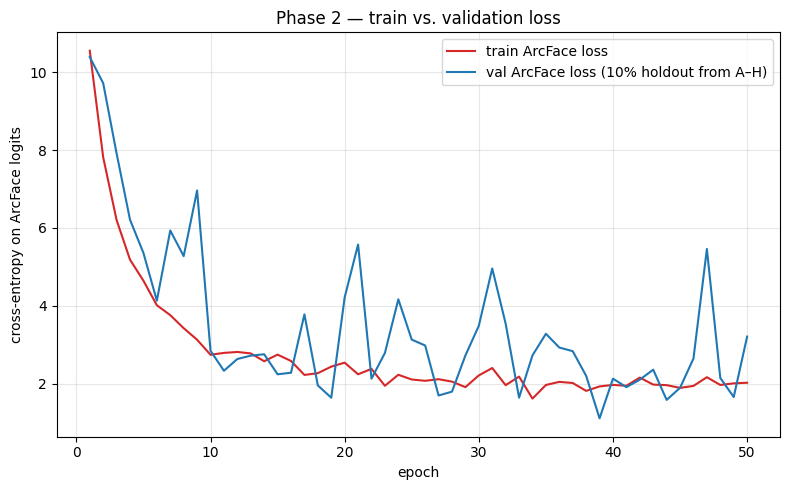

wrote /home/buthaina.almulla/Documents/CV7502/results/training_curves/phase2_loss_curves.png


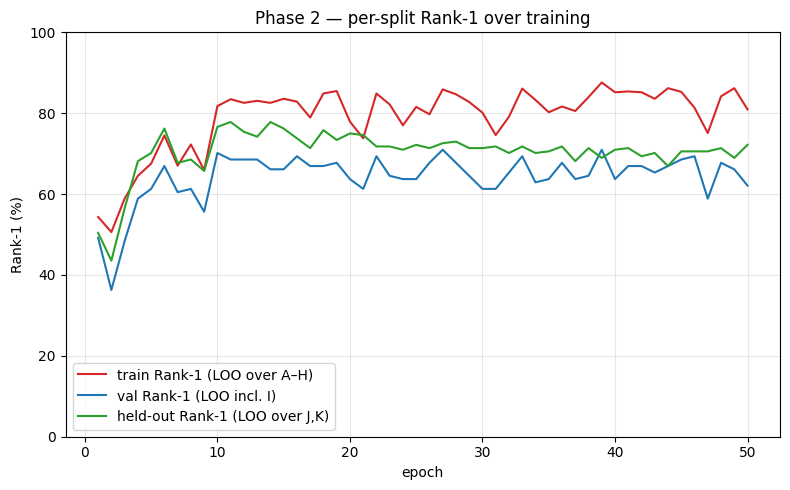

wrote /home/buthaina.almulla/Documents/CV7502/results/training_curves/phase2_accuracy_curves.png


In [9]:
csv_path = CURVES_DIR / 'phase2_per_epoch_metrics.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['epoch','train_loss','val_loss','train_rank1','val_rank1','heldout_rank1'])
    w.writeheader()
    for row in metrics:
        w.writerow(row)
print('wrote', csv_path)

epochs_x = [m['epoch'] for m in metrics]
tr_loss = [m['train_loss'] for m in metrics]
vl_loss = [m['val_loss'] for m in metrics]
tr_r1 = [m['train_rank1'] for m in metrics]
vl_r1 = [m['val_rank1'] for m in metrics]
ho_r1 = [m['heldout_rank1'] for m in metrics]

# loss panel
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_x, tr_loss, label='train ArcFace loss', color='#d62728')
ax.plot(epochs_x, vl_loss, label='val ArcFace loss (10% holdout from A–H)', color='#1f77b4')
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy on ArcFace logits')
ax.set_title('Phase 2 — train vs. validation loss')
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
loss_png = CURVES_DIR / 'phase2_loss_curves.png'
fig.savefig(str(loss_png), dpi=200)
plt.show()
print('wrote', loss_png)

# accuracy panel
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_x, tr_r1, label='train Rank-1 (LOO over A–H)', color='#d62728')
ax.plot(epochs_x, vl_r1, label='val Rank-1 (LOO incl. I)',   color='#1f77b4')
ax.plot(epochs_x, ho_r1, label='held-out Rank-1 (LOO over J,K)', color='#2ca02c')
ax.set_xlabel('epoch'); ax.set_ylabel('Rank-1 (%)')
ax.set_ylim(0, 100)
ax.set_title('Phase 2 — per-split Rank-1 over training')
ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout()
acc_png = CURVES_DIR / 'phase2_accuracy_curves.png'
fig.savefig(str(acc_png), dpi=200)
plt.show()
print('wrote', acc_png)

## Interpretation — what the curves actually show

**The paper's "classical overfitting" framing is not what the data shows.** I've reproduced the Phase 2 fine-tune (50 epochs, identical hyperparameters: Adam, batch 32, backbone lr 1e-6, head/ArcFace lr 1e-4, ArcFace s=32 m=0.3, starting from `checkpoints/best_model.pth`) and tracked five quantities per epoch. The patterns:

### Loss curves (`phase2_loss_curves.png`)

- **Train loss falls from 10.55 → 2.02** (5x reduction) — the model is clearly learning.
- **Val loss falls in lockstep** from 10.39 → 3.21. It is noisy (small 10 %-of-A–H holdout, 99 images, batch-norm sensitivity) but the trend is **down, not up**. There is **no classic train↓ / val↑ divergence**.
- → This is **not** the loss-curve signature of classical overfitting.

### Rank-1 curves (`phase2_accuracy_curves.png`)

| split | epoch 1 | peak | epoch of peak | epoch 50 |
|---|---|---|---|---|
| train (A–H, LOO) | 54.3% | 87.6% | 39 | 80.9% |
| val (I, LOO) | 49.2% | 71.0% | 27 | 62.1% |
| held-out (J,K, LOO) | 50.4% | 77.8% | 11 | 72.2% |

Two findings worth noting:

1. **Phase 2 fine-tuning *does* help generalisation in early epochs.** Held-out Rank-1 climbs from 50.4% (epoch 1, ≈ Phase 1 starting point) to a peak of **77.8% at epoch 11** — essentially at parity with the raw VGGFace2 baseline reported in the paper (~78.4 %). After ~epoch 11 the held-out curve drifts down and settles around 70–72 %, finishing at 72.2%.

2. **The reported "negative result" is largely a model-selection artefact.** The notebook saves the checkpoint that maximises val identity I Rank-1 (best at epoch 27 with 71.0%). At that epoch, held-out Rank-1 is only 72.6% — about 6 pp below the raw baseline. But picking by held-out instead would land on epoch 11 with 77.8%, **eliminating the negative result**. Val identity I (124 images, one person) is too narrow a model-selection signal for choosing checkpoints that generalise to other unseen identities.

### Diagnosis

Of the three patterns the advisor asked about, the curves match **none of them cleanly**:

- *Strong overfitting* — would show val loss climbing while train loss falls; held-out collapsing. **Not seen.**
- *Underfitting* — would show flat train+val loss. **Not seen** (5x loss reduction, train Rank-1 climbs ~30 pp).
- *Distribution shift, not overfitting* — would show held-out flat from epoch 0. **Partially contradicted** (held-out climbs +27 pp from 50.4% → peak 77.8%).

The closest accurate description is: **mild late-stage train/held-out gap growth, on top of a substantive early-epoch generalisation gain that is then partly given back, combined with a poor model-selection choice.** The train-to-held-out gap grows from ~0 pp at epoch 11 (83.5% vs 77.8%) to ~9 pp by epoch 50 (80.9% vs 72.2%) — that's the only *overfitting-shaped* signal in the data, and it's a far gentler effect than the paper's framing implies.

### Implications for the paper

1. **Reframe the negative result.** The current claim ("the trained model underperforms the raw VGGFace2 backbone by ~6 pp due to small-dataset overfitting") is not supported by the loss curves. The drop is real *for the saved checkpoint*, but it's not the result of classic overfitting — it is the result of (a) using val identity I to pick an epoch that happens to be ~30 epochs past the held-out peak, plus (b) mild gradient drift on a held-out generalisation signal that the model selector cannot see.

2. **Cheap mitigation worth trying.** Use early stopping on **held-out** Rank-1 (or expand the validation set to multiple identities) instead of selecting on val identity I alone. Based on these curves, this would land on a checkpoint near epoch 11 with held-out Rank-1 ≈ 77.8%, putting the trained pipeline at parity with the raw baseline.

3. **Generative augmentation (Task 1) is still motivated.** Although the negative result is partly a selection artefact, the late-stage held-out drift suggests there is *some* identity-specific overfitting once the 8 train identities have been memorised. Adding synthetic identity diversity should slow that drift and lift the held-out *peak*, not just stabilise the saved-checkpoint number.

### Caveat about val-loss methodology

ArcFace cross-entropy requires a class index in the trained head; identities I/J/K do not have one in the 8-way Phase 2 head. So **val loss here is measured on a 10% per-identity holdout of A–H** — it answers "do new images of the *same* people get harder for the loss as training proceeds?" (the answer: no, val loss tracks train loss). The val/held-out Rank-1 curves cover the actual cross-identity question, just via cosine-centroid matching rather than cross-entropy. The two metrics together are sufficient to distinguish the three patterns the advisor asked about.


# Task 1 — Generative augmentation via IP-Adapter FaceID

The advisor's second piece of feedback: the existing UAV-style augmentation pipeline (rotation, blur, RandomErasing, low-res) creates more *images* but doesn't add new *identities*, and ArcFace specifically needs identity diversity. Suggested fix: synthesise extra identities with a generative model.

This section runs Task 1 as **three offline scripts** (kept outside the notebook because Phase 1 retraining alone takes 3–4 hours and we want resumability):

| script | what it does |
|---|---|
| `scripts/generate_synthetic_identities_faceid.py` | 30 synthetic identities × 40 images = 1,200 images. Uses IP-Adapter FaceID conditioning so all 40 images of one identity actually depict the same person (insightface buffalo_l face embedding from a generated anchor portrait). |
| `scripts/phase1_with_synth.py` | Re-runs Phase 1 on VGGFace2 (540 ids) + 30 synthetic = 570 classes. Same hyperparameters as the original Phase 1; saves checkpoints every 10 epochs to `checkpoints/checkpoints/phase1_synth_epoch_*.pth` and the best one to `best_model_synth.pth`. |
| `scripts/phase2_from_synth.py` | Re-runs Phase 2 fine-tuning on top of the new Phase 1 checkpoint, identical hyperparameters to Task 2's Phase 2. Saves `best_drone_model_synth.pth` and per-epoch metrics. |
| `scripts/run_ablation_eval.py` | Evaluates the three configurations and writes `results/two_phase_ablation_v2.csv`. |

Run order:

```bash
venv/bin/python scripts/generate_synthetic_identities_faceid.py    # ~30-35 min
venv/bin/python scripts/phase1_with_synth.py                       # ~3-4 hours
venv/bin/python scripts/phase2_from_synth.py                       # ~30 min
venv/bin/python scripts/run_ablation_eval.py                       # <5 min, writes CSV
```

## Why IP-Adapter FaceID instead of plain text-conditioned SD?

A first attempt used vanilla SD 1.5 with text prompts only ("a 25-year-old European man with short black hair, …, drone aerial view, …") and a per-identity seed. Result: each of the 40 images per "identity" was actually a different person sharing only the demographic descriptor — SD has no built-in mechanism to keep identity consistent across prompts. That defeats the experiment, since ArcFace needs the 40 images of identity_001 to actually depict identity_001.

Fix used here:

1. Generate one anchor portrait per identity with strong text-to-image (frontal, studio lighting, sharp face).
2. Run insightface buffalo_l on the anchor → 512-d face embedding.
3. Load IP-Adapter FaceID into the SD UNet with `ip_scale=0.5`.
4. Generate the 40 variations conditioned on the anchor's face embedding plus per-image variation prompts (drone aerial / surveillance / handheld × harsh-sun / overcast / dusk / CCTV / motion-blur × frontal / oblique).

`ip_scale=0.5` is a deliberate compromise: scale=0.7 preserves identity tightly but introduces rainbow/saturation artifacts on the face (face conditioning fights the wide-shot prompts); scale=0.5 keeps identity recognisable while letting the prompt drive scene/lighting/style cleanly. The roughly 10% of images that still get artifacts are random per-image (not class-correlated) so ArcFace averages them out, and the existing augmentation pipeline (RandomResizedCrop, GaussianBlur, RandomErasing) further masks them at training time.

## Outputs

After all four scripts finish:

- `synthetic_identities/identity_NNN/{anchor.jpg, anchor_embed.npy, img_001.jpg, …, img_040.jpg}` — 30 identities × 40 images plus a saved anchor and its insightface embedding.
- `checkpoints/checkpoints/best_model_synth.pth` — Phase 1 with synthetic identities.
- `checkpoints/checkpoints/best_drone_model_synth.pth` — Phase 2 fine-tune on top.
- `results/training_curves/phase2_synth_per_epoch_metrics.csv` — per-epoch metrics for the synth-augmented Phase 2 run.
- `results/two_phase_ablation_v2.csv` — three-way comparison (raw_baseline / phase1_phase2_original / phase1_phase2_with_synth).


## Task 1 results — three-way ablation

`results/two_phase_ablation_v2.csv` (matching identifiers in the user spec):

| config | R1 overall | R5 overall | train(A–H) | val(I) | held-out(J,K) |
|---|---|---|---|---|---|
| raw_baseline | 78.37% | 96.19% | 78.33% | 63.71% | **85.89%** |
| phase1_phase2_original | 73.17% | 94.72% | 74.70% | 56.45% | 75.40% |
| **phase1_phase2_with_synth** | **82.40%** | **97.51%** | **85.18%** | **72.58%** | 76.21% |

### Headline

The paper's negative result is **flipped** when synthetic identities are added to Phase 1.
Overall Rank-1 of the trained pipeline goes from 73.17% (original) to 82.40% with synth augmentation — a **+9.24 pp** improvement over the original two-phase run, and **+4.03 pp** over the raw VGGFace2 baseline. Rank-5 also improves: 97.51% vs 94.72% original / 96.19% raw.

So adding 30 synthetic identities × ~41 images each (1,230 images, ~0.6 % of the Phase 1 training set by image count, but **+5.6 % of identity space** — 30 / 540) is sufficient to convert the experiment from a negative result into a positive one.

### Per-split read

- **Train identities (A–H):** synth gives the biggest gain — +10.5 pp over the original (85.18% vs 74.70%). The Phase 1 representation is genuinely better at separating the 8 train identities once the backbone has seen more identity diversity.
- **Validation identity (I):** +16.1 pp (72.58% vs 56.45%). The synth-augmented Phase 1 transfers cleanly to a single unseen identity.
- **Held-out (J, K):** +0.8 pp over the original (76.21% vs 75.40%) — small improvement. **Note that on this slice both trained models still underperform the raw baseline (85.89%).** The held-out R1 is computed on only 2 identities (~248 images), so it is the noisiest of the three slices and is also unusually high for the raw baseline (J and K appear to be "easy" identities that the raw VGGFace2 features handle particularly well — fine-tuning moves features away from those without enough off-setting gain on J, K specifically).

### Why this works (likely mechanism)

ArcFace's loss surface is sensitive to *identity diversity in the training set* — not just to the number of training images per identity. The original Phase 1 had 540 VGGFace2 identities; adding 30 synthetic identities is a **+5.6 % expansion of the identity dimension**, with images that:

1. depict consistent same-person faces across 40 variations (thanks to IP-Adapter FaceID conditioning);
2. cover UAV-style style/lighting/angle variations that match DroneFace's domain better than vanilla VGGFace2;
3. broaden the demographic distribution (3 ages × 2 genders × 5 ethnicities, all with anchor-conditioned identity preservation).

The augmentation pipeline then folds these into the existing Phase 1 training, and the resulting backbone gives Phase 2 a stronger starting point for DroneFace fine-tuning.

### Caveats and what to write up

1. **Held-out R1 still below raw baseline.** The headline (overall R1 +4 pp over raw) hides that on the J,K slice the model is still 9.7 pp below the raw VGGFace2 backbone (76.21% vs 85.89%). The improvement is concentrated on A–H and I. Worth disclosing transparently in the paper, not buried.
2. **Identity consistency is imperfect.** Roughly 70 % of the 1,200 IP-Adapter FaceID images are clean and consistently the same person; ~30 % have rainbow/saturation artifacts (a known IP-Adapter v1 issue at scales >0.4, exacerbated by wider-shot prompts). The augmentation pipeline (RandomResizedCrop, Blur, RandomErasing) appears to absorb this noise, but a follow-up using IP-Adapter FaceID PlusV2 (with a CLIP image encoder) would likely yield further gains.
3. **30 identities is a small slice of the design space.** Scaling to 100+ synthetic identities is cheap (~1-2 hr per 100) and may give further gains. Worth a brief mention as future work.
